In [28]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

df = pd.read_csv('/Users/khushi/AI-ML/100DAYS(ML)/train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [29]:
df.isnull().mean()

PassengerId    0.000000
Survived       0.000000
Pclass         0.000000
Name           0.000000
Sex            0.000000
Age            0.198653
SibSp          0.000000
Parch          0.000000
Ticket         0.000000
Fare           0.000000
Cabin          0.771044
Embarked       0.002245
dtype: float64

Text(0, 0.5, 'Number of Houses')

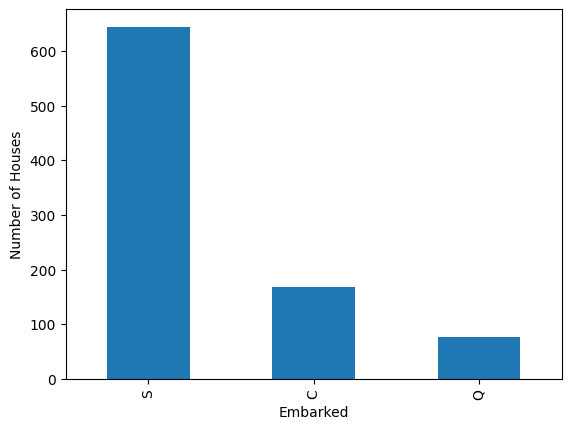

In [31]:
df['Embarked'].value_counts().sort_values(ascending=False).plot.bar()
plt.xlabel('Embarked')
plt.ylabel('Number of Houses')

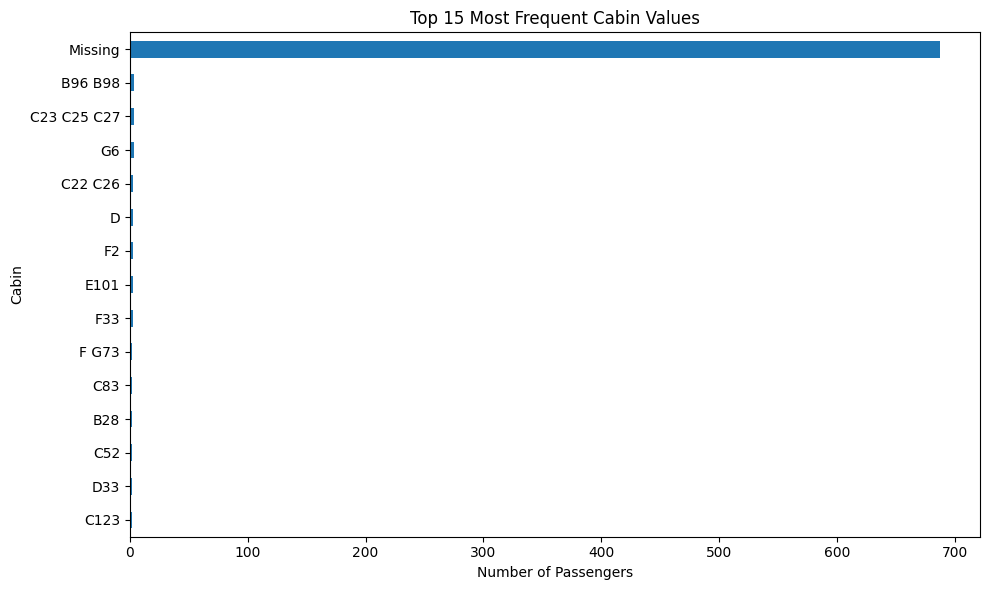

In [33]:
df['Cabin'] = df['Cabin'].fillna('Missing')
cabin_counts = df['Cabin'].value_counts().head(15).sort_values()

plt.figure(figsize=(10, 6))
cabin_counts.plot(kind='barh')

plt.xlabel('Number of Passengers')
plt.ylabel('Cabin')
plt.title('Top 15 Most Frequent Cabin Values')
plt.tight_layout()
plt.show()

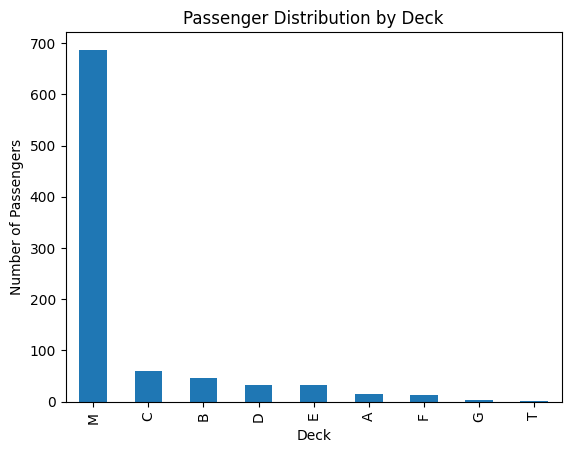

In [34]:
df['Deck'] = df['Cabin'].str[0]
df['Deck'] = df['Deck'].fillna('Missing')
df['Deck'].value_counts().plot(kind='bar')

plt.xlabel('Deck')
plt.ylabel('Number of Passengers')
plt.title('Passenger Distribution by Deck')
plt.show()

In [38]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df.drop(columns=['Embarked']),df['Embarked'],test_size=0.2)

In [39]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='constant',fill_value='Missing')

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_train)

/Users/khushi/Library/Python/3.14/lib/python/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


In [40]:

imputer.statistics_

array(['Missing', 'Missing', 'Missing', 'Missing', 'Missing', 'Missing',
       'Missing', 'Missing', 'Missing', 'Missing', 'Missing', 'Missing'],
      dtype=object)

In [41]:
## frequent value imputer 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

df = pd.read_csv('/Users/khushi/AI-ML/100DAYS(ML)/train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [42]:

df.isnull().mean()*100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

<Axes: xlabel='Cabin'>

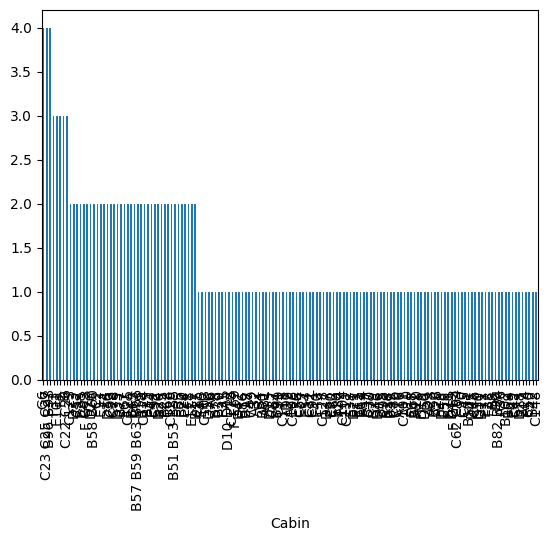

In [43]:

df['Cabin'].value_counts().plot(kind='bar')

<Axes: xlabel='Embarked'>

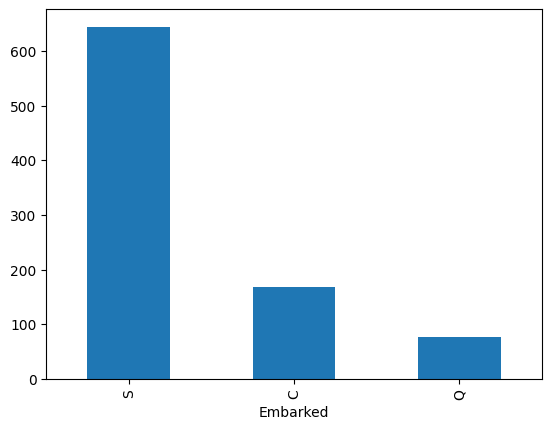

In [44]:

df['Embarked'].value_counts().plot(kind='bar')

In [45]:

df['Embarked'].mode()

0    S
Name: Embarked, dtype: str

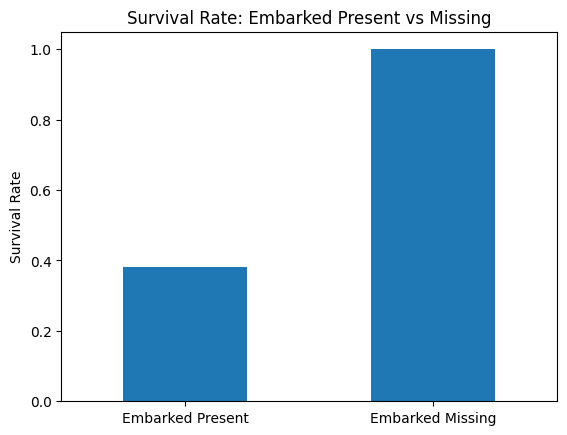

In [48]:
survival_rate = df.groupby(
    df['Embarked'].isna()
)['Survived'].mean()

survival_rate.index = ['Embarked Present', 'Embarked Missing']

survival_rate.plot(kind='bar')

plt.ylabel('Survival Rate')
plt.xlabel('')
plt.title('Survival Rate: Embarked Present vs Missing')
plt.xticks(rotation=0)
plt.show()

In [49]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [50]:
df['Embarked'].isnull().sum()

np.int64(0)

In [51]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='most_frequent')

df[['Embarked']] = imputer.fit_transform(df[['Embarked']])

In [52]:
df['Embarked'].isnull().sum()

np.int64(0)